# 03 — Exploratory Data Analysis

## The drivers of economic growth in Europe: evidence from productivity and investment

This notebook answers four descriptive questions:

1. How are GDP growth, productivity growth, and investment distributed?
2. How strongly are the variables associated in the pooled data?
3. How did the European averages change between 2000 and 2018?
4. Do the relationships remain visible across countries and within countries over time?

The balanced core panel is used throughout the main analysis. Education expenditure appears only in a clearly labelled supplementary section because its coverage is incomplete.

In [189]:
# Import the required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

# Plot settings
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

## 1. Data import and validation

We import the balanced core panel and the extended panel produced during data cleaning. Basic validation checks ensure that the correct datasets are used in the exploratory analysis.

In [ ]:
# Locate the project folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

processed_dir = project_dir / "data" / "processed"
core_file = processed_dir / "europe_panel_core_cleaned.csv"
extended_file = processed_dir / "europe_panel_extended_cleaned.csv"

missing_files = [path for path in [core_file, extended_file] if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Run 02_data_cleaning.ipynb first. Missing: "
        + ", ".join(str(path) for path in missing_files)
    )

core = pd.read_csv(core_file)
extended = pd.read_csv(extended_file)

print("Core sample dimensions:", core.shape)
print("Extended sample dimensions:", extended.shape)
display(core.head())
display(extended.head())

In [191]:
# Variables in the main and extended analyses
core_variables = [
    "GDP Growth",
    "Investment",
    "Productivity Growth"
]

extended_variables = [
    "GDP Growth",
    "Investment",
    "Education Expenditure",
    "Productivity Growth"
]

def validate_eda_input(data, required_variables):
    """
    Validate a dataset before exploratory analysis.
    """
    print("Observations:", len(data))
    print("Countries:", data["Country Code"].nunique())
    print("Period:", data["Year"].min(), "-", data["Year"].max())

    print(
        "Duplicate country-years:",
        data.duplicated(
            subset=["Country Code", "Year"]
        ).sum()
    )

    print(
        "Missing required values:",
        data[required_variables].isna().sum().sum()
    )

    print(
        "Infinite required values:",
        np.isinf(
            data[required_variables].to_numpy()
        ).sum()
    )


print("CORE SAMPLE")
validate_eda_input(core, core_variables)

print("\nEXTENDED SAMPLE")
validate_eda_input(extended, extended_variables)

CORE SAMPLE
Observations: 779
Countries: 41
Period: 2000 - 2018
Duplicate country-years: 0
Missing required values: 0
Infinite required values: 0

EXTENDED SAMPLE
Observations: 614
Countries: 40
Period: 2000 - 2018
Duplicate country-years: 0
Missing required values: 0
Infinite required values: 0


## 2. Descriptive statistics

We summarise the central tendency, dispersion, and range of each economic variable. Differences between means and medians can indicate skewed distributions or the influence of extreme macroeconomic observations.

In [192]:
def descriptive_statistics(data, variables):
    """
    Produce an expanded descriptive-statistics table.
    """
    statistics = data[variables].describe().T

    statistics["Median"] = data[variables].median()
    statistics["Variance"] = data[variables].var()
    statistics["Skewness"] = data[variables].skew()
    statistics["Kurtosis"] = data[variables].kurt()

    return statistics[
        [
            "count",
            "mean",
            "Median",
            "std",
            "Variance",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "Skewness",
            "Kurtosis"
        ]
    ]


core_statistics = descriptive_statistics(
    core,
    core_variables
)

extended_statistics = descriptive_statistics(
    extended,
    extended_variables
)

print("CORE SAMPLE")
display(core_statistics.round(3))

print("EXTENDED SAMPLE")
display(extended_statistics.round(3))

CORE SAMPLE


,count,mean,Median,std,Variance,min,25%,50%,75%,max,Skewness,Kurtosis
GDP Growth,779.000,2.823,2.824,3.688,13.599,-16.040,1.228,2.824,4.725,24.624,-0.492,5.081
Investment,779.000,23.660,22.857,5.052,25.527,9.064,20.387,22.857,26.337,43.666,0.753,1.097
Productivity Growth,779.000,2.095,1.600,3.289,10.818,-11.300,0.255,1.600,3.560,20.930,0.879,3.501


EXTENDED SAMPLE


,count,mean,Median,std,Variance,min,25%,50%,75%,max,Skewness,Kurtosis
GDP Growth,614.000,2.831,2.779,3.660,13.396,-16.040,1.317,2.779,4.681,24.624,-0.609,5.795
Investment,614.000,23.875,23.233,4.920,24.211,11.888,20.695,23.233,26.359,43.666,0.819,1.259
Education Expenditure,614.000,5.145,4.974,1.252,1.567,2.823,4.179,4.974,5.795,9.510,0.596,-0.133
Productivity Growth,614.000,2.090,1.655,3.120,9.736,-11.300,0.268,1.655,3.528,20.930,1.003,4.715


### What the distributions show

GDP and productivity growth contain heavy tails because the period includes severe recessions and unusually rapid expansions. Investment is less volatile because it is measured as a share of GDP. These patterns justify retaining the full sample while checking whether extreme observations influence the conclusions.

### Distribution of the core variables

Histograms and kernel-density curves show the shape of each distribution. The dashed line represents the sample mean, while the dotted line represents the median.

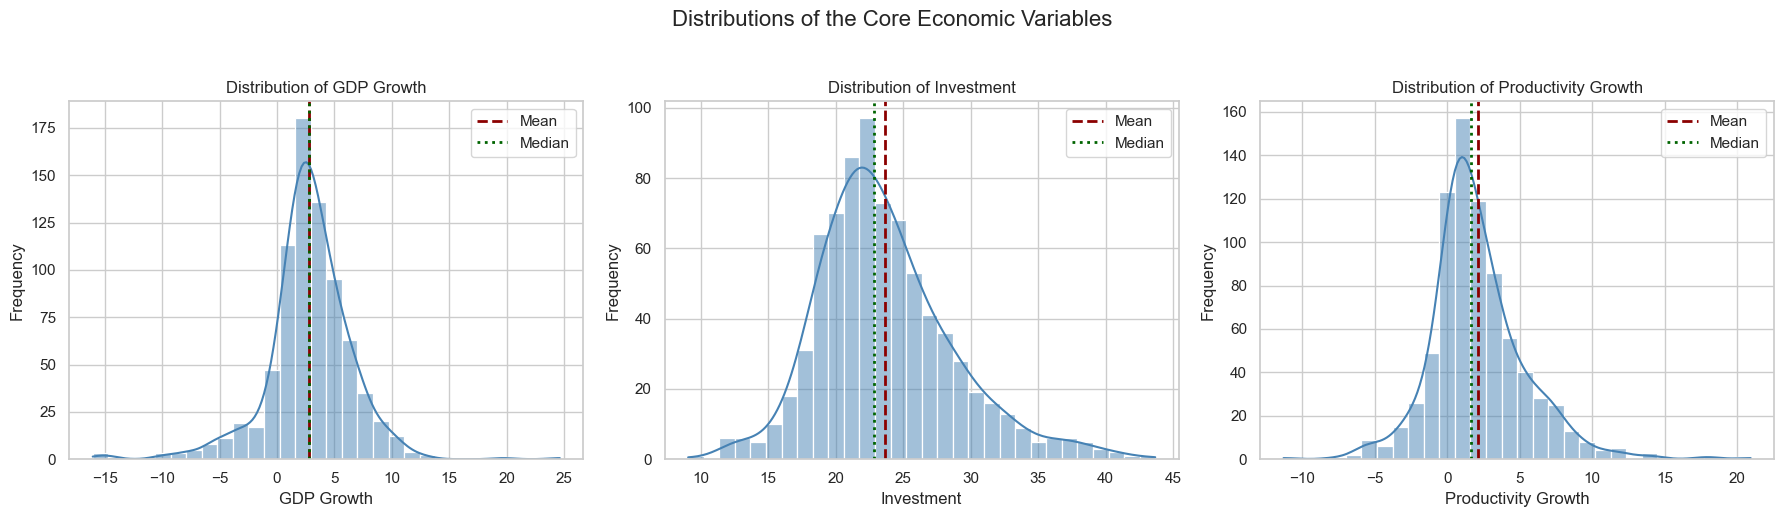

In [193]:
# Plot distributions of the core variables
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)

for axis, variable in zip(axes, core_variables):
    sns.histplot(
        data=core,
        x=variable,
        bins=30,
        kde=True,
        color="steelblue",
        ax=axis
    )

    axis.axvline(
        core[variable].mean(),
        color="darkred",
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    axis.axvline(
        core[variable].median(),
        color="darkgreen",
        linestyle=":",
        linewidth=2,
        label="Median"
    )

    axis.set_title(f"Distribution of {variable}")
    axis.set_ylabel("Frequency")
    axis.legend()

plt.suptitle(
    "Distributions of the Core Economic Variables",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

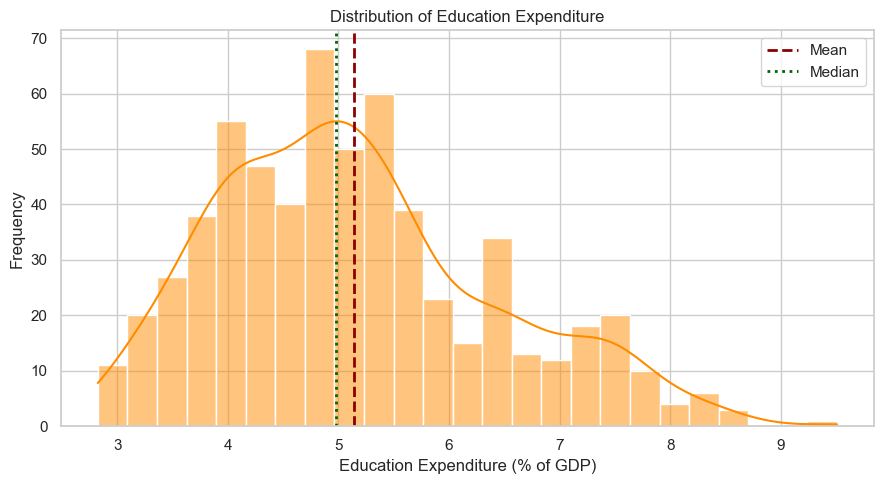

In [194]:
# Plot the distribution of education expenditure
plt.figure(figsize=(9, 5))

sns.histplot(
    data=extended,
    x="Education Expenditure",
    bins=25,
    kde=True,
    color="darkorange"
)

plt.axvline(
    extended["Education Expenditure"].mean(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.axvline(
    extended["Education Expenditure"].median(),
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label="Median"
)

plt.title("Distribution of Education Expenditure")
plt.xlabel("Education Expenditure (% of GDP)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Observations flagged during cleaning

The cleaning flag identifies country–years containing at least one IQR-based extreme value. The comparison below describes the two groups; it does not redefine the main sample.

In [195]:
print(core["Potential_Outlier"].value_counts(dropna=False))
print("\nData type:", core["Potential_Outlier"].dtype)

Potential_Outlier
False    682
True      97
Name: count, dtype: int64

Data type: bool


In [196]:
outlier_comparison = (
    core.groupby("Potential_Outlier")[core_variables]
    .agg(["count", "mean", "median", "std"])
)

display(outlier_comparison.round(3))

GDP Growth                    Investment                \
                       count  mean median   std      count   mean median   
Potential_Outlier                                                          
False                    682 2.923  2.779 2.500        682 23.281 22.681   
True                      97 2.120  4.800 8.081         97 26.326 24.217   

                        Productivity Growth                     
                    std               count  mean median   std  
Potential_Outlier                                               
False             4.214                 682 1.894  1.520 2.323  
True              8.527                  97 3.503  4.590 6.863

## 3. Correlation analysis

We calculate pairwise Pearson correlations to measure the direction and strength of linear associations between the variables. Correlation is descriptive and does not establish causality.

In [197]:
# Pearson correlations in the balanced core sample
core_correlation = core[
    core_variables
].corr(method="pearson")

display(core_correlation.round(3))

,GDP Growth,Investment,Productivity Growth
GDP Growth,1.000,0.392,0.701
Investment,0.392,1.000,0.267
Productivity Growth,0.701,0.267,1.000


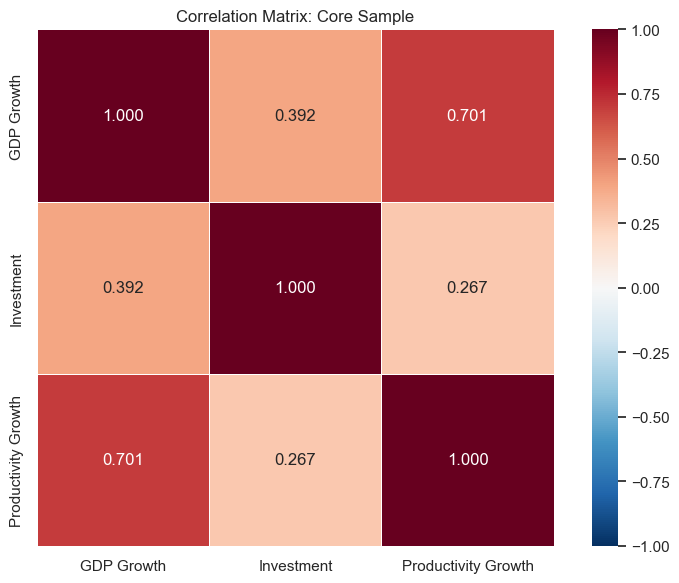

In [198]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    core_correlation,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix: Core Sample")
plt.tight_layout()
plt.show()

,GDP Growth,Investment,Education Expenditure,Productivity Growth
GDP Growth,1.000,0.379,-0.177,0.719
Investment,0.379,1.000,-0.170,0.272
Education Expenditure,-0.177,-0.170,1.000,-0.141
Productivity Growth,0.719,0.272,-0.141,1.000


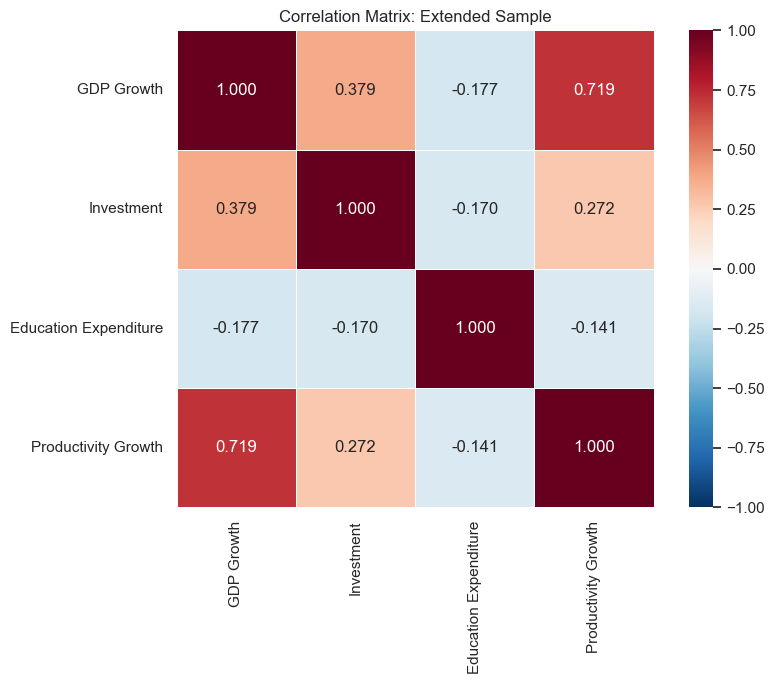

In [199]:
extended_correlation = extended[
    extended_variables
].corr(method="pearson")

display(extended_correlation.round(3))

plt.figure(figsize=(9, 7))

sns.heatmap(
    extended_correlation,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix: Extended Sample")
plt.tight_layout()
plt.show()

### Interpretation of the correlations

In the **balanced core sample**, GDP growth has a strong positive correlation with productivity growth (**0.701**) and a moderate positive correlation with investment (**0.392**). Investment and productivity growth are only weakly correlated (**0.267**), which reduces concern that they provide the same information.

In the smaller education sample, education expenditure is weakly negatively correlated with contemporaneous GDP growth. This should not be treated as evidence that education reduces growth: education may operate with long lags, the variable is divided by GDP, and the sample composition changes across countries and years.

## 4. Pairwise relationships

Scatter plots provide a visual assessment of the relationships between GDP growth and its potential drivers. Linear regression lines summarise the average associations, but they do not represent causal estimates.

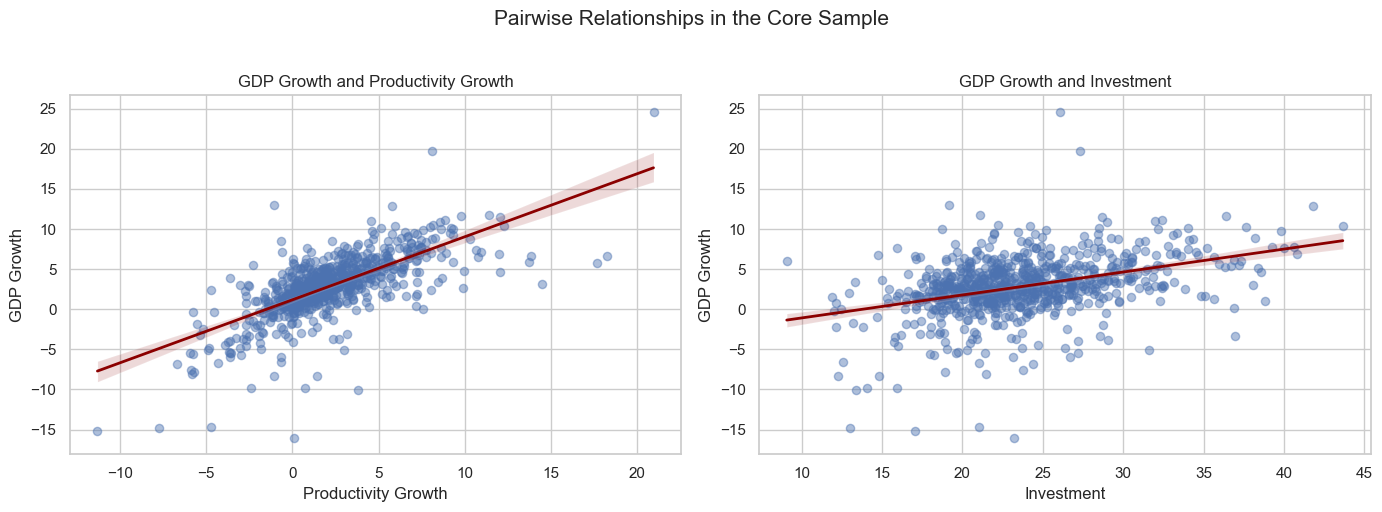

In [200]:
# Plot GDP growth against the core explanatory variables
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

sns.regplot(
    data=core,
    x="Productivity Growth",
    y="GDP Growth",
    scatter_kws={
        "alpha": 0.45,
        "s": 35
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[0]
)

axes[0].set_title("GDP Growth and Productivity Growth")

sns.regplot(
    data=core,
    x="Investment",
    y="GDP Growth",
    scatter_kws={
        "alpha": 0.45,
        "s": 35
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[1]
)

axes[1].set_title("GDP Growth and Investment")

plt.suptitle(
    "Pairwise Relationships in the Core Sample",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

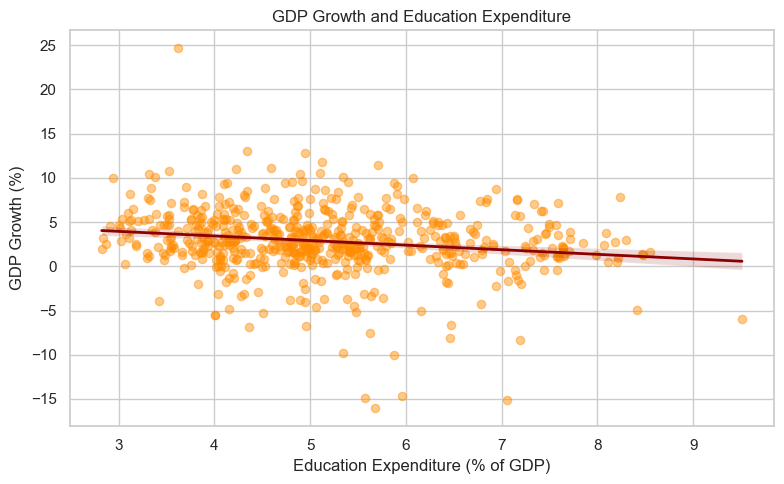

In [201]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=extended,
    x="Education Expenditure",
    y="GDP Growth",
    scatter_kws={
        "alpha": 0.45,
        "s": 35,
        "color": "darkorange"
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    }
)

plt.title("GDP Growth and Education Expenditure")
plt.xlabel("Education Expenditure (% of GDP)")
plt.ylabel("GDP Growth (%)")

plt.tight_layout()
plt.show()

## 5. Evolution over time

Annual cross-country averages show how economic growth, investment, and productivity evolved across Europe between 2000 and 2018. Because the variables have different scales, GDP growth and productivity growth are displayed together, while investment is shown separately.

In [202]:
# Calculate annual cross-country statistics
annual_core = (
    core
    .groupby("Year")[core_variables]
    .agg(["mean", "median", "std"])
)

# Simplify the column names
annual_core.columns = [
    f"{variable}_{statistic}"
    for variable, statistic in annual_core.columns
]

annual_core = annual_core.reset_index()

display(annual_core.round(3))

,Year,GDP Growth_mean,GDP Growth_median,GDP Growth_std,Investment_mean,Investment_median,Investment_std,Productivity Growth_mean,Productivity Growth_median,Productivity Growth_std
0,2000,5.167,4.524,3.045,23.865,23.947,4.419,4.496,3.390,3.072
1,2001,3.113,2.917,2.739,23.739,22.657,4.542,2.579,2.130,3.342
2,2002,3.422,3.225,2.354,23.166,21.605,4.590,3.169,2.150,3.459
3,2003,3.572,3.195,2.772,23.489,22.232,4.529,3.414,2.390,3.554
4,2004,5.152,4.736,2.708,24.550,23.824,4.399,4.994,3.750,3.690
5,2005,4.485,3.897,2.613,25.189,23.965,4.846,3.399,2.490,3.159
6,2006,5.449,5.070,2.466,26.617,24.543,5.607,3.285,2.860,2.744
7,2007,5.504,5.310,2.646,28.020,26.671,5.515,2.960,2.430,2.634
8,2008,2.380,1.972,3.394,27.852,25.937,5.323,0.813,0.120,3.597
9,2009,-5.024,-4.587,4.198,22.165,21.403,4.543,-2.408,-2.700,3.579


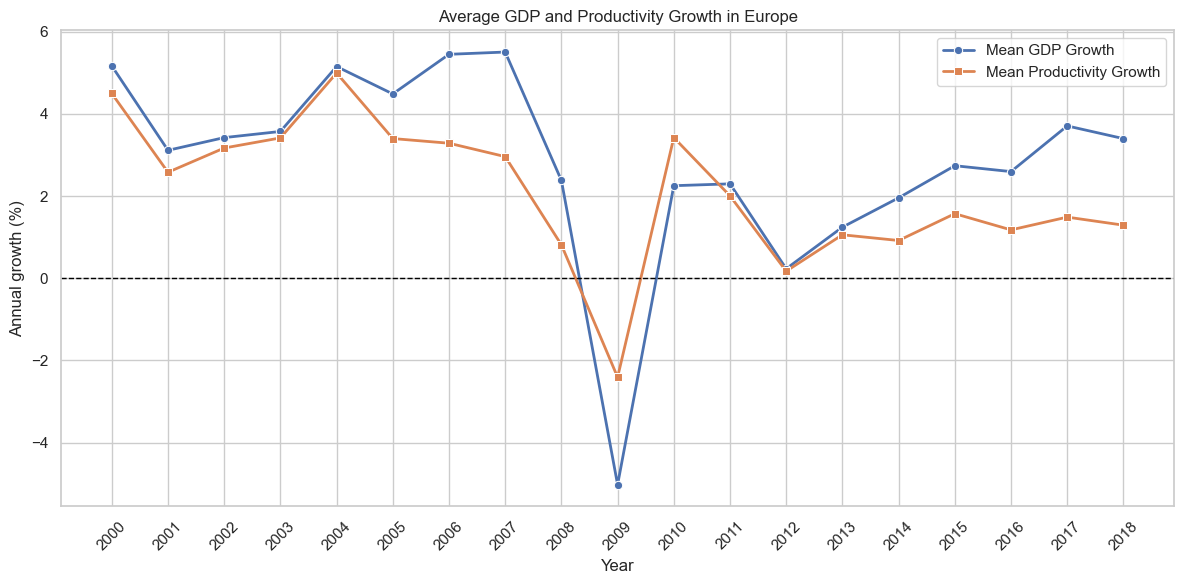

In [203]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=annual_core,
    x="Year",
    y="GDP Growth_mean",
    marker="o",
    linewidth=2,
    label="Mean GDP Growth"
)

sns.lineplot(
    data=annual_core,
    x="Year",
    y="Productivity Growth_mean",
    marker="s",
    linewidth=2,
    label="Mean Productivity Growth"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Average GDP and Productivity Growth in Europe")
plt.xlabel("Year")
plt.ylabel("Annual growth (%)")
plt.xticks(
    annual_core["Year"],
    rotation=45
)
plt.legend()
plt.tight_layout()
plt.show()

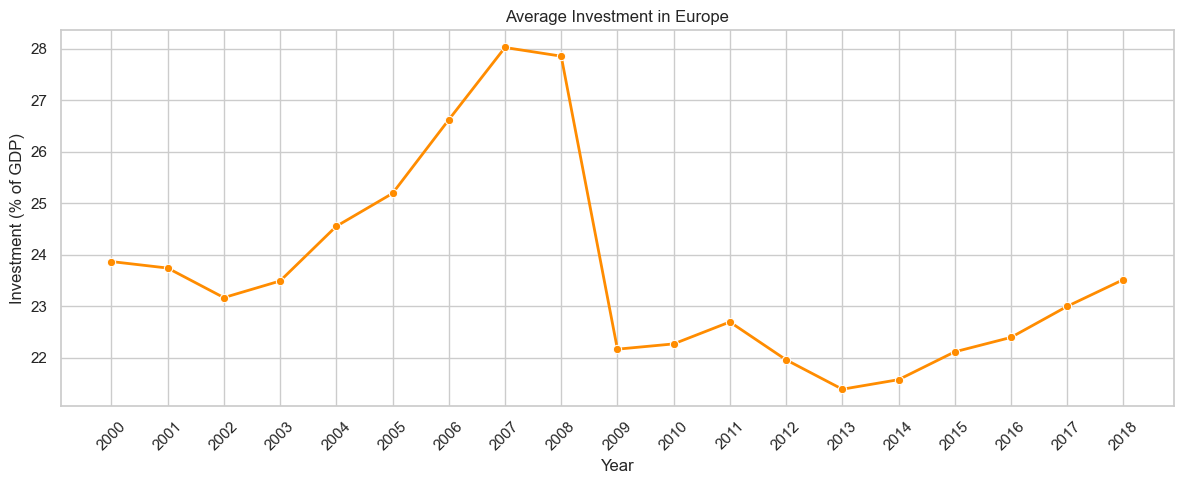

In [204]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=annual_core,
    x="Year",
    y="Investment_mean",
    marker="o",
    color="darkorange",
    linewidth=2
)

plt.title("Average Investment in Europe")
plt.xlabel("Year")
plt.ylabel("Investment (% of GDP)")
plt.xticks(
    annual_core["Year"],
    rotation=45
)

plt.tight_layout()
plt.show()

In [205]:
def classify_period(year):
    """
    Classify observations into broad economic periods.
    """
    if year <= 2007:
        return "Pre-crisis (2000–2007)"
    elif year <= 2009:
        return "Global crisis (2008–2009)"
    elif year <= 2013:
        return "European debt crisis (2010–2013)"
    else:
        return "Recovery (2014–2018)"


core["Economic Period"] = (
    core["Year"]
    .apply(classify_period)
)

period_order = [
    "Pre-crisis (2000–2007)",
    "Global crisis (2008–2009)",
    "European debt crisis (2010–2013)",
    "Recovery (2014–2018)"
]

period_statistics = (
    core
    .groupby(
        "Economic Period",
        observed=False
    )[core_variables]
    .agg(["mean", "median", "std"])
    .reindex(period_order)
)

display(period_statistics.round(3))

GDP Growth              Investment         \
                                       mean median   std       mean median   
Economic Period                                                              
Pre-crisis (2000–2007)                4.483  4.175 2.801     24.829 23.780   
Global crisis (2008–2009)            -1.322 -0.973 5.317     25.008 23.998   
European debt crisis (2010–2013)      1.505  1.529 2.979     22.076 21.628   
Recovery (2014–2018)                  2.879  2.672 2.870     22.518 22.170   

                                       Productivity Growth               
                                   std                mean median   std  
Economic Period                                                          
Pre-crisis (2000–2007)           5.034               3.537  2.905 3.279  
Global crisis (2008–2009)        5.690              -0.798 -1.150 3.917  
European debt crisis (2010–2013) 4.806               1.664  1.425 2.556  
Recovery (2014–2018)             4.377               1.289  0.950 2.280

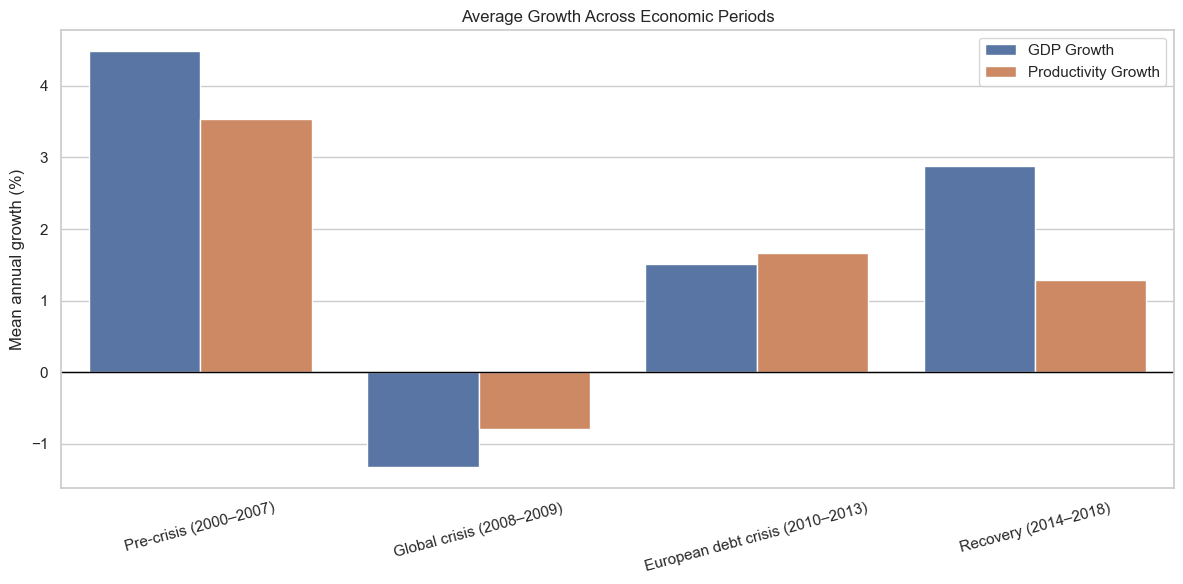

In [206]:
period_means = (
    core
    .groupby("Economic Period")[core_variables]
    .mean()
    .reindex(period_order)
    .reset_index()
)

period_growth_long = period_means.melt(
    id_vars="Economic Period",
    value_vars=[
        "GDP Growth",
        "Productivity Growth"
    ],
    var_name="Variable",
    value_name="Mean"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=period_growth_long,
    x="Economic Period",
    y="Mean",
    hue="Variable"
)

plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.title("Average Growth Across Economic Periods")
plt.xlabel("")
plt.ylabel("Mean annual growth (%)")
plt.xticks(rotation=15)
plt.legend(title="")

plt.tight_layout()
plt.show()

### Interpretation of economic periods

European economic performance differs considerably across the four periods. The pre-crisis period records the highest average GDP and productivity growth. Both variables become negative during the global financial crisis, confirming the severity of the common macroeconomic shock.

Growth returns during the European debt crisis, although it remains substantially below its pre-crisis level. During the 2014–2018 recovery, average GDP growth strengthens, while productivity growth remains comparatively modest. Thus, GDP and productivity generally move in the same direction, but the post-crisis recovery does not restore the high productivity growth observed before 2008.

## 6. Cross-country comparison

Country-level averages reveal persistent differences in growth, investment, and productivity across Europe. Since simple averages may be influenced by extreme annual observations, both means and medians are reported.

In [207]:
# Calculate country-level summary statistics
country_statistics = (
    core
    .groupby(
        ["Country Code", "Country Name"]
    )
    .agg(
        Mean_GDP_Growth=("GDP Growth", "mean"),
        Median_GDP_Growth=("GDP Growth", "median"),
        GDP_Growth_Volatility=("GDP Growth", "std"),
        Mean_Investment=("Investment", "mean"),
        Mean_Productivity_Growth=("Productivity Growth", "mean"),
        Median_Productivity_Growth=(
            "Productivity Growth",
            "median"
        ),
        Productivity_Volatility=(
            "Productivity Growth",
            "std"
        )
    )
    .reset_index()
)

display(
    country_statistics
    .sort_values(
        "Mean_GDP_Growth",
        ascending=False
    )
    .round(3)
)

,Country Code,Country Name,Mean_GDP_Growth,Median_GDP_Growth,GDP_Growth_Volatility,Mean_Investment,Mean_Productivity_Growth,Median_Productivity_Growth,Productivity_Volatility
39,TUR,Turkiye,5.203,5.806,4.406,27.858,2.969,3.430,3.993
27,MLT,Malta,5.164,4.102,4.980,21.159,1.447,1.090,2.597
19,IRL,Ireland,4.999,5.306,6.375,25.302,3.207,2.310,5.037
5,BLR,Belarus,4.708,5.045,4.361,31.180,4.809,5.640,3.640
25,MDA,Moldova,4.528,5.000,3.678,26.204,5.527,5.730,4.909
0,ALB,Albania,4.330,3.909,2.157,32.834,3.617,4.840,4.342
22,LTU,Lithuania,4.296,4.612,5.357,21.956,4.469,4.790,4.265
12,EST,Estonia,4.078,5.635,5.802,29.449,3.356,3.470,4.064
24,LVA,Latvia,4.077,4.310,6.576,28.848,4.115,3.820,3.250
33,ROU,Romania,4.019,4.496,4.077,25.391,5.308,5.200,4.827


In [208]:
# Countries with the highest average GDP growth
highest_growth = (
    country_statistics
    .nlargest(10, "Mean_GDP_Growth")
    [
        [
            "Country Name",
            "Mean_GDP_Growth",
            "Mean_Productivity_Growth",
            "Mean_Investment"
        ]
    ]
)

# Countries with the lowest average GDP growth
lowest_growth = (
    country_statistics
    .nsmallest(10, "Mean_GDP_Growth")
    [
        [
            "Country Name",
            "Mean_GDP_Growth",
            "Mean_Productivity_Growth",
            "Mean_Investment"
        ]
    ]
)

print("HIGHEST AVERAGE GDP GROWTH")
display(highest_growth.round(3))

print("LOWEST AVERAGE GDP GROWTH")
display(lowest_growth.round(3))

HIGHEST AVERAGE GDP GROWTH


,Country Name,Mean_GDP_Growth,Mean_Productivity_Growth,Mean_Investment
39,Turkiye,5.203,2.969,27.858
27,Malta,5.164,1.447,21.159
19,Ireland,4.999,3.207,25.302
5,Belarus,4.708,4.809,31.180
25,Moldova,4.528,5.527,26.204
0,Albania,4.330,3.617,32.834
22,Lithuania,4.296,4.469,21.956
12,Estonia,4.078,3.356,29.449
24,Latvia,4.077,4.115,28.848
33,Romania,4.019,5.308,25.391


LOWEST AVERAGE GDP GROWTH


,Country Name,Mean_GDP_Growth,Mean_Productivity_Growth,Mean_Investment
21,Italy,0.380,-0.219,20.079
16,Greece,0.506,0.357,19.119
32,Portugal,0.794,0.801,20.903
10,Denmark,1.356,0.911,21.306
9,Germany,1.403,0.667,20.292
14,France,1.457,0.763,21.872
29,Netherlands,1.584,0.763,20.593
1,Austria,1.630,0.637,24.350
13,Finland,1.633,0.861,23.475
2,Belgium,1.641,0.788,23.412


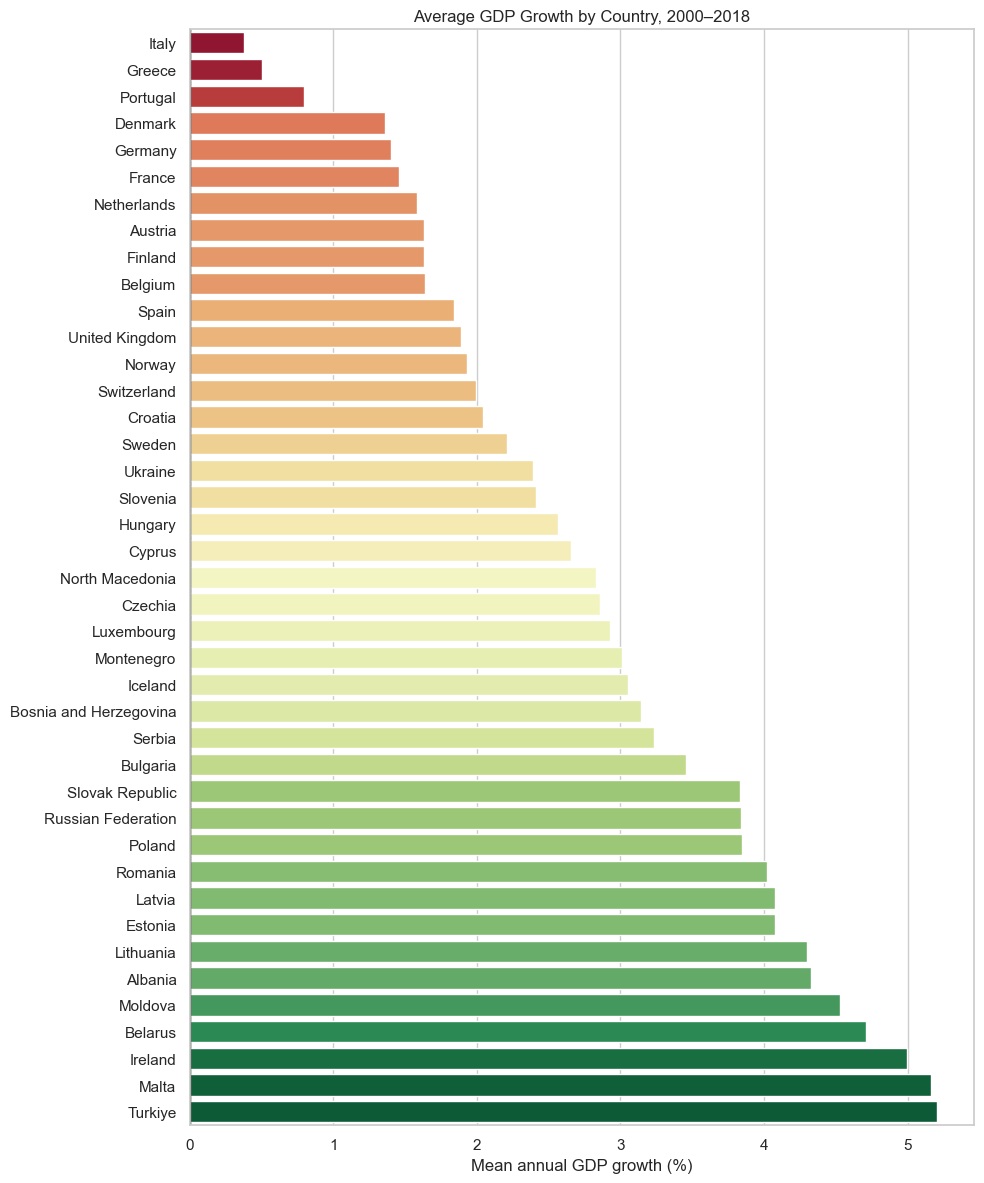

In [209]:
# Rank all countries by average GDP growth
growth_ranking = (
    country_statistics
    .sort_values(
        "Mean_GDP_Growth",
        ascending=True
    )
)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=growth_ranking,
    x="Mean_GDP_Growth",
    y="Country Name",
    hue="Mean_GDP_Growth",
    palette="RdYlGn",
    legend=False
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Average GDP Growth by Country, 2000–2018")
plt.xlabel("Mean annual GDP growth (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

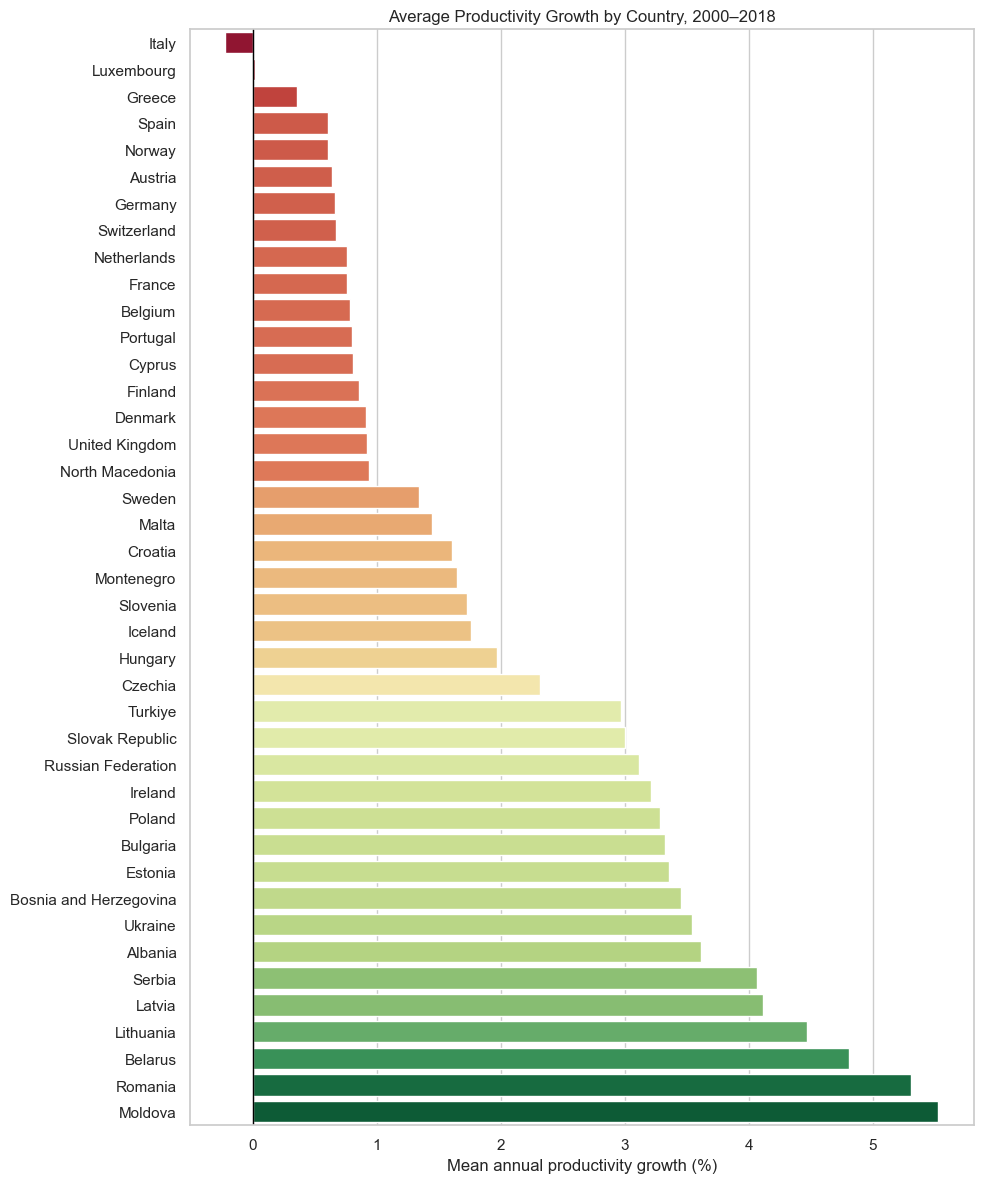

In [210]:
# Rank countries by average productivity growth
productivity_ranking = (
    country_statistics
    .sort_values(
        "Mean_Productivity_Growth",
        ascending=True
    )
)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=productivity_ranking,
    x="Mean_Productivity_Growth",
    y="Country Name",
    hue="Mean_Productivity_Growth",
    palette="RdYlGn",
    legend=False
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title(
    "Average Productivity Growth by Country, 2000–2018"
)
plt.xlabel("Mean annual productivity growth (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

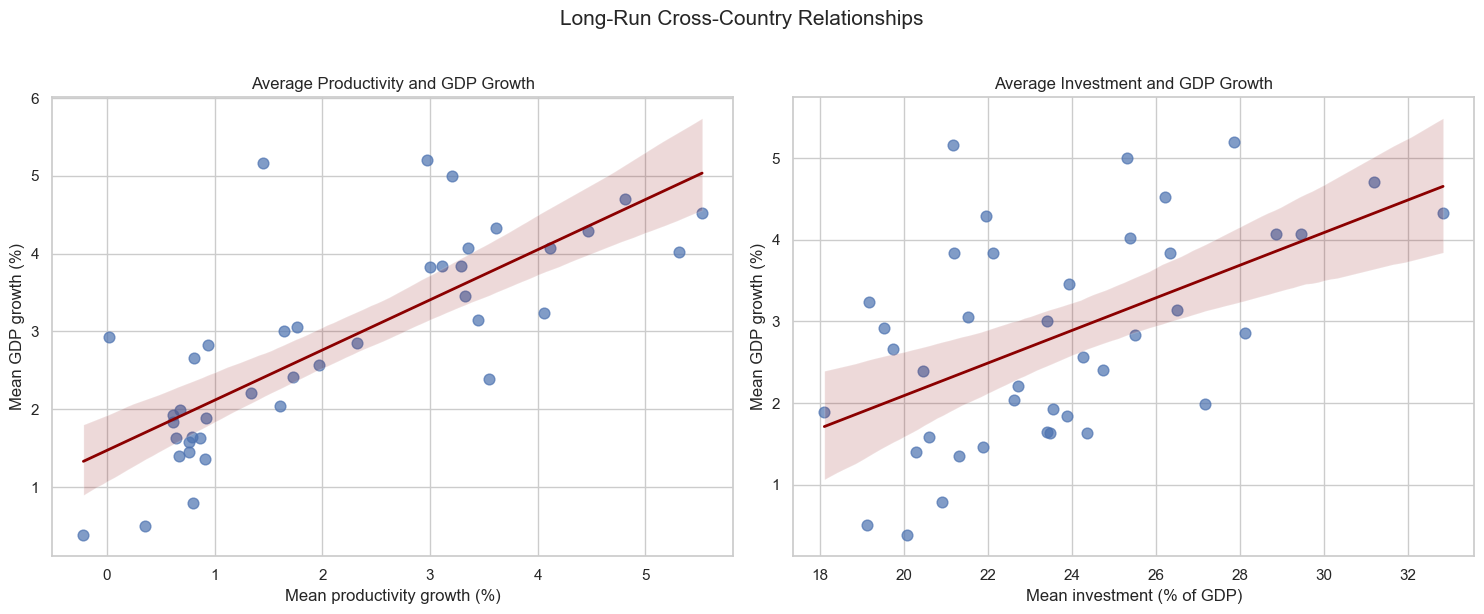

In [211]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

sns.regplot(
    data=country_statistics,
    x="Mean_Productivity_Growth",
    y="Mean_GDP_Growth",
    scatter_kws={
        "s": 60,
        "alpha": 0.7
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[0]
)

axes[0].set_title(
    "Average Productivity and GDP Growth"
)
axes[0].set_xlabel("Mean productivity growth (%)")
axes[0].set_ylabel("Mean GDP growth (%)")

sns.regplot(
    data=country_statistics,
    x="Mean_Investment",
    y="Mean_GDP_Growth",
    scatter_kws={
        "s": 60,
        "alpha": 0.7
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[1]
)

axes[1].set_title(
    "Average Investment and GDP Growth"
)
axes[1].set_xlabel("Mean investment (% of GDP)")
axes[1].set_ylabel("Mean GDP growth (%)")

plt.suptitle(
    "Long-Run Cross-Country Relationships",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

### Interpretation of long-run cross-country relationships

The country-level results show positive associations between both potential drivers and average GDP growth. The relationship between productivity and GDP growth appears comparatively strong, with observations more closely concentrated around the fitted line. Countries experiencing faster average productivity growth generally also record higher average economic growth.

Average investment is also positively related to GDP growth, although the observations are more dispersed. This suggests that countries with similar investment shares can experience different growth outcomes, possibly because investment effectiveness, institutional conditions, sectoral composition, and other country-specific characteristics also matter.

These relationships are descriptive and should not be interpreted as causal effects. They reflect differences between countries and do not control for unobserved country characteristics or common European shocks.

In [212]:
# Correlations based on country averages
country_average_correlations = (
    country_statistics[
        [
            "Mean_GDP_Growth",
            "Mean_Investment",
            "Mean_Productivity_Growth"
        ]
    ]
    .corr()
)

display(country_average_correlations.round(3))

,Mean_GDP_Growth,Mean_Investment,Mean_Productivity_Growth
Mean_GDP_Growth,1.000,0.530,0.774
Mean_Investment,0.530,1.000,0.500
Mean_Productivity_Growth,0.774,0.500,1.000


In [213]:
print(
    "GDP growth and productivity:",
    round(
        country_average_correlations.loc[
            "Mean_GDP_Growth",
            "Mean_Productivity_Growth"
        ],
        3
    )
)

print(
    "GDP growth and investment:",
    round(
        country_average_correlations.loc[
            "Mean_GDP_Growth",
            "Mean_Investment"
        ],
        3
    )
)

GDP growth and productivity: 0.774
GDP growth and investment: 0.53


## 7. Within-country relationships

Country-demeaned variables measure each observation relative to that country's 2000–2018 average. The results therefore ask whether a country tends to grow faster in years when its own productivity growth or investment is unusually high.

This removes persistent country differences but not common European year shocks. The two-way adjustment below removes both sources of variation and provides a descriptive bridge to the fixed-effects regression.

In [214]:
# Create country-demeaned variables
within_data = core.copy()

for variable in core_variables:
    within_data[f"{variable}_Within"] = (
        within_data[variable]
        - within_data.groupby("Country Code")[variable].transform("mean")
    )

within_variables = [
    "GDP Growth_Within",
    "Investment_Within",
    "Productivity Growth_Within"
]

within_correlations = (
    within_data[within_variables]
    .corr()
)

display(within_correlations.round(3))

,GDP Growth_Within,Investment_Within,Productivity Growth_Within
GDP Growth_Within,1.000,0.386,0.695
Investment_Within,0.386,1.000,0.169
Productivity Growth_Within,0.695,0.169,1.000


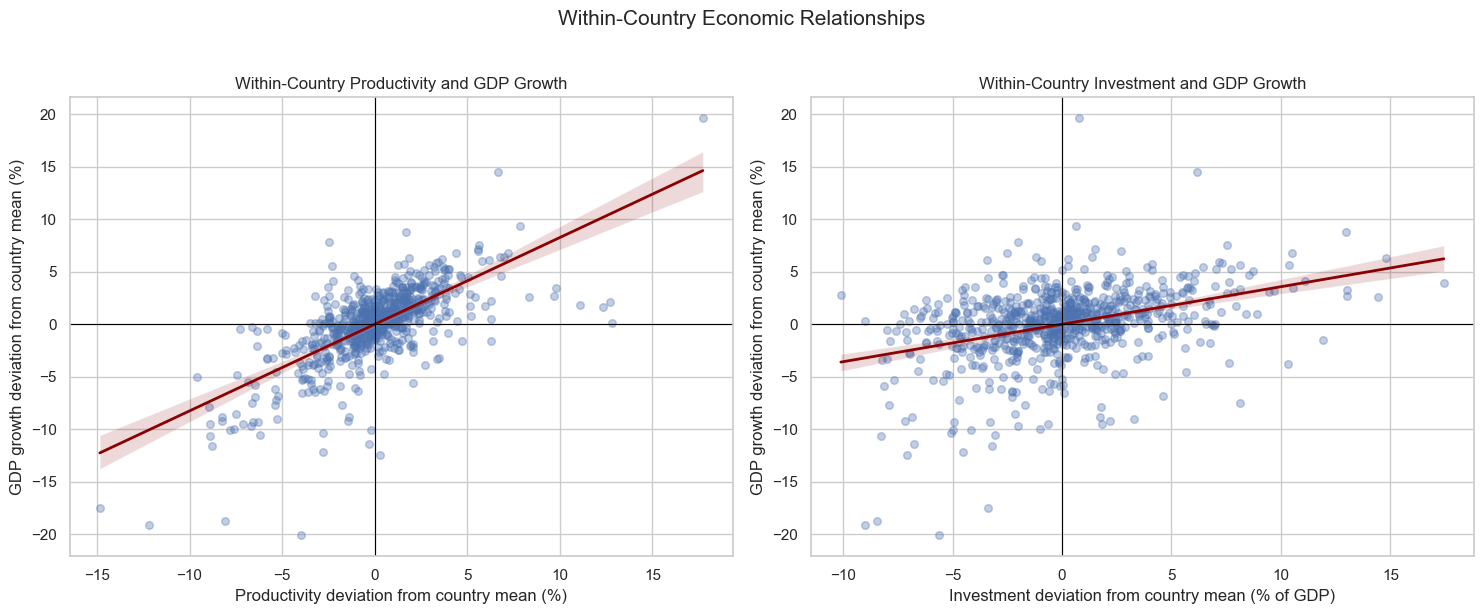

In [215]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

sns.regplot(
    data=within_data,
    x="Productivity Growth_Within",
    y="GDP Growth_Within",
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[0]
)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Within-Country Productivity and GDP Growth")
axes[0].set_xlabel("Productivity deviation from country mean (%)")
axes[0].set_ylabel("GDP growth deviation from country mean (%)")

sns.regplot(
    data=within_data,
    x="Investment_Within",
    y="GDP Growth_Within",
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[1]
)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Within-Country Investment and GDP Growth")
axes[1].set_xlabel("Investment deviation from country mean (% of GDP)")
axes[1].set_ylabel("GDP growth deviation from country mean (%)")

plt.suptitle(
    "Within-Country Economic Relationships",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

In [216]:
within_gdp_productivity = within_correlations.loc[
    "GDP Growth_Within",
    "Productivity Growth_Within"
]

within_gdp_investment = within_correlations.loc[
    "GDP Growth_Within",
    "Investment_Within"
]

print(
    "Within-country correlation between GDP and productivity growth:",
    round(within_gdp_productivity, 3)
)

print(
    "Within-country correlation between GDP growth and investment:",
    round(within_gdp_investment, 3)
)

Within-country correlation between GDP and productivity growth: 0.695
Within-country correlation between GDP growth and investment: 0.386


### Interpretation of within-country relationships

The within-country correlations describe whether a country tends to grow faster in years when productivity growth or investment is above its own long-run average. This differs from the country-level analysis, which compares average economic performance across countries.

A positive within-country productivity coefficient would indicate that above-average productivity growth generally coincides with above-average GDP growth. A positive investment coefficient would indicate that years of relatively high investment are also associated with stronger growth.

These remain descriptive relationships. Country demeaning removes time-invariant country characteristics, but it does not control for common annual shocks affecting all European countries.

### Two-way demeaned relationships

Two-way demeaning removes both persistent country differences and common year-specific movements. The remaining variation represents country-specific deviations after accounting for country averages and Europe-wide annual shocks.

In [217]:
# Create two-way demeaned variables
two_way_data = core.copy()

for variable in core_variables:
    country_mean = (
        two_way_data
        .groupby("Country Code")[variable]
        .transform("mean")
    )

    year_mean = (
        two_way_data
        .groupby("Year")[variable]
        .transform("mean")
    )

    overall_mean = two_way_data[variable].mean()

    two_way_data[f"{variable}_TwoWay"] = (
        two_way_data[variable]
        - country_mean
        - year_mean
        + overall_mean
    )

two_way_variables = [
    "GDP Growth_TwoWay",
    "Investment_TwoWay",
    "Productivity Growth_TwoWay"
]

two_way_correlations = (
    two_way_data[two_way_variables]
    .corr()
)

display(two_way_correlations.round(3))

,GDP Growth_TwoWay,Investment_TwoWay,Productivity Growth_TwoWay
GDP Growth_TwoWay,1.000,0.321,0.594
Investment_TwoWay,0.321,1.000,0.090
Productivity Growth_TwoWay,0.594,0.090,1.000


In [218]:
print(
    "Two-way correlation between GDP and productivity growth:",
    round(
        two_way_correlations.loc[
            "GDP Growth_TwoWay",
            "Productivity Growth_TwoWay"
        ],
        3
    )
)

print(
    "Two-way correlation between GDP growth and investment:",
    round(
        two_way_correlations.loc[
            "GDP Growth_TwoWay",
            "Investment_TwoWay"
        ],
        3
    )
)

Two-way correlation between GDP and productivity growth: 0.594
Two-way correlation between GDP growth and investment: 0.321


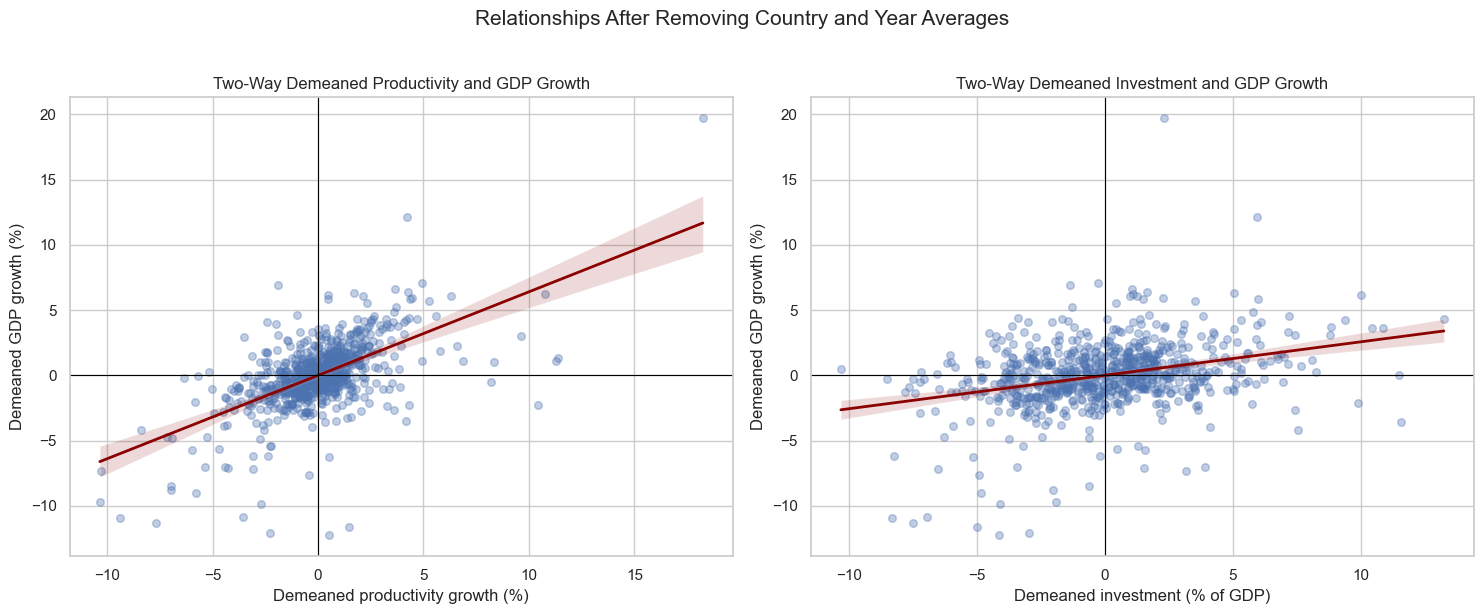

In [219]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

sns.regplot(
    data=two_way_data,
    x="Productivity Growth_TwoWay",
    y="GDP Growth_TwoWay",
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[0]
)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Two-Way Demeaned Productivity and GDP Growth")
axes[0].set_xlabel("Demeaned productivity growth (%)")
axes[0].set_ylabel("Demeaned GDP growth (%)")

sns.regplot(
    data=two_way_data,
    x="Investment_TwoWay",
    y="GDP Growth_TwoWay",
    scatter_kws={
        "alpha": 0.35,
        "s": 30
    },
    line_kws={
        "color": "darkred",
        "linewidth": 2
    },
    ax=axes[1]
)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Two-Way Demeaned Investment and GDP Growth")
axes[1].set_xlabel("Demeaned investment (% of GDP)")
axes[1].set_ylabel("Demeaned GDP growth (%)")

plt.suptitle(
    "Relationships After Removing Country and Year Averages",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

In [220]:
correlation_comparison = pd.DataFrame({
    "Variation": [
        "Pooled country-years",
        "Between countries",
        "Within countries",
        "Country and year adjusted"
    ],
    "GDP–Productivity Correlation": [
        core_correlation.loc[
            "GDP Growth",
            "Productivity Growth"
        ],
        country_average_correlations.loc[
            "Mean_GDP_Growth",
            "Mean_Productivity_Growth"
        ],
        within_gdp_productivity,
        two_way_correlations.loc[
            "GDP Growth_TwoWay",
            "Productivity Growth_TwoWay"
        ]
    ],
    "GDP–Investment Correlation": [
        core_correlation.loc[
            "GDP Growth",
            "Investment"
        ],
        country_average_correlations.loc[
            "Mean_GDP_Growth",
            "Mean_Investment"
        ],
        within_gdp_investment,
        two_way_correlations.loc[
            "GDP Growth_TwoWay",
            "Investment_TwoWay"
        ]
    ]
})

display(correlation_comparison.round(3))

,Variation,GDP–Productivity Correlation,GDP–Investment Correlation
0,Pooled country-years,0.701,0.392
1,Between countries,0.774,0.530
2,Within countries,0.695,0.386
3,Country and year adjusted,0.594,0.321


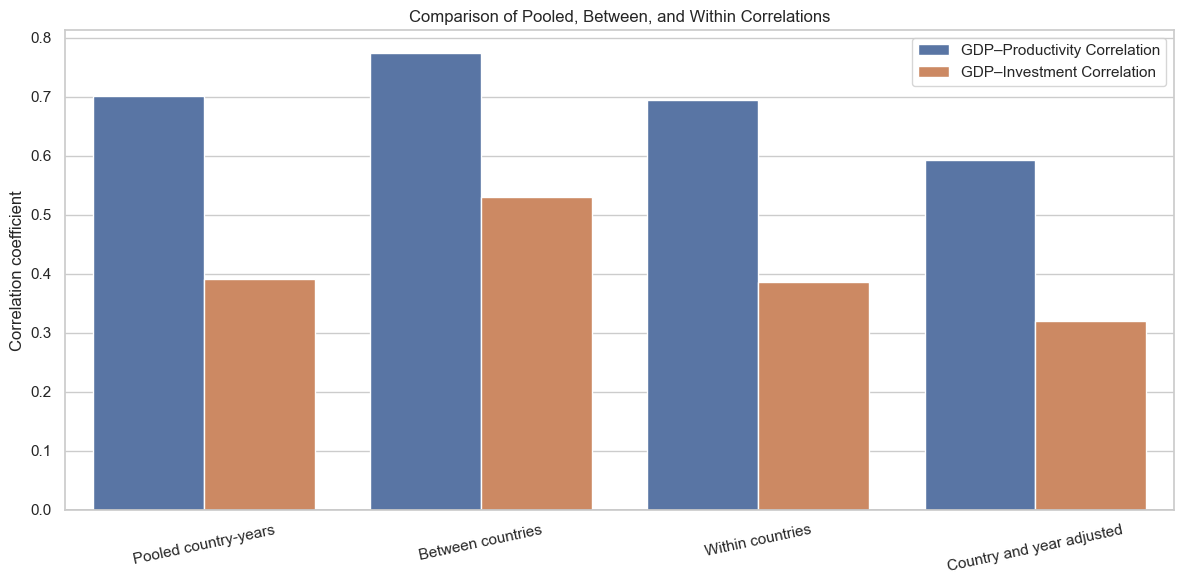

In [221]:
correlation_comparison_long = correlation_comparison.melt(
    id_vars="Variation",
    var_name="Relationship",
    value_name="Correlation"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=correlation_comparison_long,
    x="Variation",
    y="Correlation",
    hue="Relationship"
)

plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.title("Comparison of Pooled, Between, and Within Correlations")
plt.xlabel("")
plt.ylabel("Correlation coefficient")
plt.xticks(rotation=12)
plt.legend(title="")

plt.tight_layout()
plt.show()

### Comparison of different sources of variation

The pooled correlation combines differences across countries with changes within countries over time. The between-country correlation focuses on long-run differences in average economic performance, while the within-country correlation removes persistent country characteristics.

The two-way adjusted correlation additionally removes common annual movements across Europe. Differences between these coefficients indicate that the observed relationships depend partly on whether the analysis compares countries, compares years within countries, or controls for common macroeconomic shocks.

## 8. Sensitivity to potential outliers

The correlations are recalculated after excluding observations flagged by the IQR diagnostic. This is only a sensitivity check: the full sample remains preferred because extreme values often represent genuine crises, recessions, and recoveries.

In [222]:
# Sample excluding observations flagged by the IQR diagnostic
core_without_flagged = (
    core.loc[~core["Potential_Outlier"]]
    .copy()
)

correlation_without_flagged = (
    core_without_flagged[core_variables]
    .corr()
)

outlier_robustness = pd.DataFrame({
    "Relationship": [
        "GDP Growth and Productivity Growth",
        "GDP Growth and Investment",
        "Investment and Productivity Growth"
    ],
    "Full Sample": [
        core_correlation.loc[
            "GDP Growth",
            "Productivity Growth"
        ],
        core_correlation.loc[
            "GDP Growth",
            "Investment"
        ],
        core_correlation.loc[
            "Investment",
            "Productivity Growth"
        ]
    ],
    "Without Flagged Observations": [
        correlation_without_flagged.loc[
            "GDP Growth",
            "Productivity Growth"
        ],
        correlation_without_flagged.loc[
            "GDP Growth",
            "Investment"
        ],
        correlation_without_flagged.loc[
            "Investment",
            "Productivity Growth"
        ]
    ]
})

outlier_robustness["Difference"] = (
    outlier_robustness["Without Flagged Observations"]
    - outlier_robustness["Full Sample"]
)

print("Full-sample observations:", len(core))
print(
    "Observations without flagged values:",
    len(core_without_flagged)
)

display(outlier_robustness.round(3))

Full-sample observations: 779
Observations without flagged values: 682


,Relationship,Full Sample,Without Flagged Observations,Difference
0,GDP Growth and Productivity Growth,0.701,0.644,-0.058
1,GDP Growth and Investment,0.392,0.355,-0.037
2,Investment and Productivity Growth,0.267,0.203,-0.065


## 9. Supplementary education analysis

Annual education averages are plotted together with the number of countries observed in each year. This is essential because a change in the annual average may reflect **changing sample composition**, not only a genuine change in expenditure.

In [223]:
annual_extended = (
    extended
    .groupby("Year")
    .agg(
        Countries=("Country Code", "nunique"),
        Mean_Education_Expenditure=(
            "Education Expenditure",
            "mean"
        ),
        Median_Education_Expenditure=(
            "Education Expenditure",
            "median"
        ),
        Mean_GDP_Growth=("GDP Growth", "mean")
    )
    .reset_index()
)

display(annual_extended.round(3))

,Year,Countries,Mean_Education_Expenditure,Median_Education_Expenditure,Mean_GDP_Growth
0,2000,27,4.826,4.659,4.961
1,2001,30,4.883,4.835,3.804
2,2002,32,5.008,5.178,3.425
3,2003,30,5.151,5.277,3.756
4,2004,32,5.108,5.047,5.230
5,2005,30,5.215,5.087,4.399
6,2006,28,5.238,4.998,5.520
7,2007,31,5.084,4.891,5.545
8,2008,31,5.302,5.023,1.821
9,2009,31,5.667,5.563,-5.513


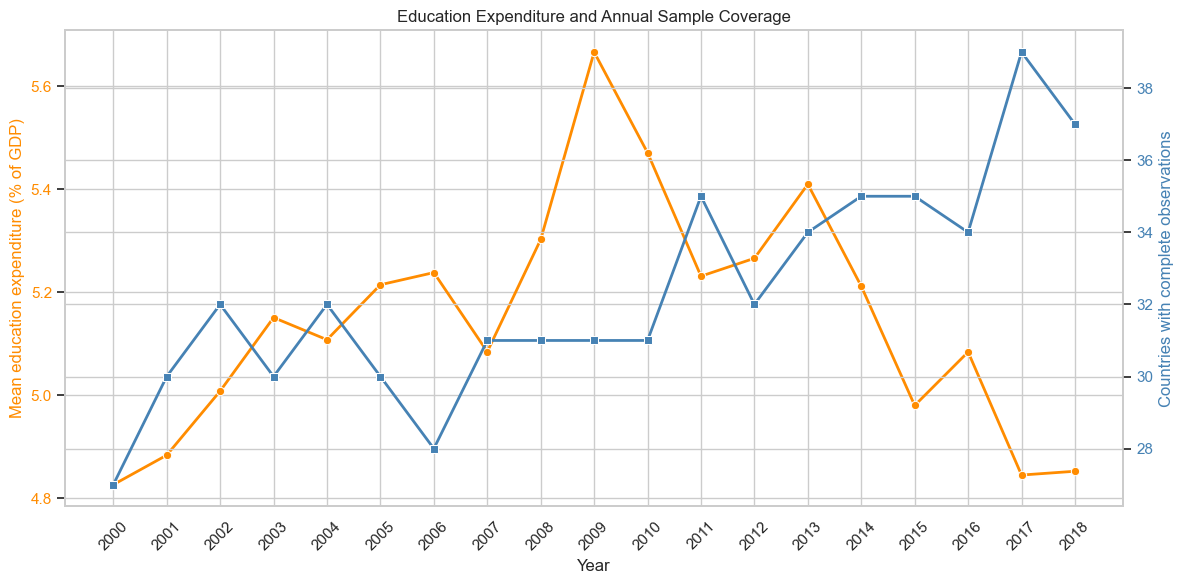

In [224]:
fig, axis_education = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=annual_extended,
    x="Year",
    y="Mean_Education_Expenditure",
    marker="o",
    color="darkorange",
    linewidth=2,
    ax=axis_education
)

axis_education.set_xlabel("Year")
axis_education.set_ylabel(
    "Mean education expenditure (% of GDP)",
    color="darkorange"
)
axis_education.tick_params(
    axis="y",
    labelcolor="darkorange"
)

axis_coverage = axis_education.twinx()

sns.lineplot(
    data=annual_extended,
    x="Year",
    y="Countries",
    marker="s",
    color="steelblue",
    linewidth=2,
    ax=axis_coverage
)

axis_coverage.set_ylabel(
    "Countries with complete observations",
    color="steelblue"
)
axis_coverage.tick_params(
    axis="y",
    labelcolor="steelblue"
)

axis_education.set_title(
    "Education Expenditure and Annual Sample Coverage"
)
axis_education.set_xticks(annual_extended["Year"])
axis_education.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Exploratory conclusions

- **Productivity growth has the strongest descriptive link with GDP growth.** The pooled correlation is 0.701, and the relationship remains positive between countries, within countries, and after removing country and year averages.
- **Investment is also positively associated with GDP growth**, but its correlations are smaller and its country-level relationship is more dispersed. The amount invested may not capture investment quality or composition.
- **Common European shocks matter.** Average GDP and productivity growth fall sharply during the global financial crisis, motivating the use of year fixed effects in the regression notebook.
- **Extreme observations are economically meaningful.** Removing IQR-flagged observations weakens but does not reverse the main descriptive relationships.
- **Education remains supplementary.** Its incomplete coverage and likely delayed effects make a contemporaneous comparison difficult to interpret.

These findings motivate a two-way fixed-effects model that controls for persistent country characteristics and common annual shocks. The next notebook estimates that model while keeping the conclusions explicitly associational rather than causal.